# Apprentissage supervisé — prédire la classe de consommation d'alcool

## L'idée : une vraie variable, mais dans l'esprit des clusters K-means

Ce notebook complète les deux directions explorées jusqu'ici :

- **`apprentissage_*_kmeans`** : prédire des clusters — des classes *artificielles*, géométriquement
  optimisées pour être séparables dans l'espace ACP. Résultat : 85-93% d'accuracy, mais en grande partie
  circulaire (les clusters sont une fonction directe des variables qui servent ensuite à les prédire)
- **`apprentissage_supervisé_oracle`** : prédire de *vraies* variables comportementales (`famsup`,
  `activities`, `romantic`, `paid`). Résultat : quasi rien — 6 cibles sur 8 n'avaient aucun signal détectable
  (η² < 0.06 partout), une conclusion en soi très informative sur l'indépendance de ces comportements vis-à-vis
  du contexte familial/scolaire

**Ici, on prend une vraie variable — `classe_alcool` (la consommation d'alcool, déjà construite et explorée
dans `analyse.ipynb`) — mais on la place dans la position des clusters** : on lui donne accès à *tout* le
jeu de variables, notes comprises (`G1`, `G2`, `G3`). C'est légitime cette fois : `classe_alcool` n'est pas
une fonction des notes, donc l'inclure ne crée aucune circularité — au contraire, ça permet de poser une
vraie question : **la consommation d'alcool est-elle liée à la performance scolaire, ou en est-elle
indépendante ?**

La seule règle de fuite qui reste : exclure **`Dalc`** et **`Walc`**, les deux variables qui *définissent*
littéralement la cible (`classe_alcool` = fonction de `Dalc` et `Walc` — les inclure serait aussi tautologique
qu'inclure `G1`/`G2` pour prédire la moyenne).

## La question posée

Où `classe_alcool` se situe-t-elle entre les deux extrêmes déjà observés ?
- **Proche des clusters** (très prédictible, 85%+) → ce serait surprenant : ça voudrait dire que la
  consommation d'alcool est en réalité une expression directe du profil scolaire/familial
- **Proche de l'oracle** (quasi nulle, ~naïf) → ça confirmerait que c'est un comportement largement
  indépendant du reste, comme `famsup`/`romantic`
- **Quelque part entre les deux** → un signal réel mais modeste, porté par des variables qu'on peut
  interpréter — le scénario le plus probable, et le plus intéressant à creuser

## Méthodologie reconduite

Comme pour `apprentissage_reussite` : sélection ANOVA (η² > 0.06), **vérification systématique de
l'homoscédasticité** avant d'interpréter LDA/QDA (verdict explicite, à la Box/TP09), puis comparaison
KNN / LDA (`LinearDiscriminantAnalysis()`, sans shrinkage) / QDA (`QuadraticDiscriminantAnalysis()`, sans
`reg_param`) / régression logistique.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

student_mat = pd.read_csv("donnees/student-mat.csv")
student_por = pd.read_csv("donnees/student-por.csv")

## 1. Construire la cible — `classe_alcool`, retravaillée pour des classes homogènes

On reprend le score combiné déjà construit dans `analyse.ipynb` (`score = Dalc × 2 + Walc`, qui pondère
plus lourdement la consommation en semaine — signe d'une consommation installée plutôt qu'occasionnelle).
En revanche, on retravaille les **seuils de discrétisation** : la version originale (`score == 3` /
`score ∈ [4,7]` / `score > 7`) donne des classes déséquilibrées (≈ 38% / 44% / 18% — `Régulier` nettement
sous-représentée), exactement le problème qu'on a corrigé pour le niveau scolaire en passant à des tertiles.

**Mais un tertile strict est ici impossible** : `pd.qcut(score, 3)` échoue, car 37-38% des élèves partagent
*la même valeur plancher* (`score = 3`, c'est-à-dire `Dalc = 1` et `Walc = 1` — aucune consommation du tout).
Aucun seuil ne peut découper ce groupe ; toute discrétisation en 3 classes aura donc nécessairement un
premier groupe d'au moins ~37%. On choisit alors les seuils qui **équilibrent au mieux les deux groupes
restants**, en cherchant un découpage qui fonctionne identiquement sur les deux datasets (condition
essentielle pour rester comparable) :

| Classe | Score | Logique |
|---|---|---|
| `Non-consommateur` | = 3 | Aucune consommation (`Dalc=1`, `Walc=1`) — le plancher incompressible |
| `Modéré` | 4-5 | Consommation occasionnelle/légère |
| `Régulier` | ≥ 6 | Consommation installée, au moins l'un des deux contextes nettement marqué |

Avec ce découpage, les trois classes tombent à ≈ 37-38% / 27-28% / 35% sur les deux datasets — on ne peut
pas faire mieux qu'environ 37/31/31 vu la contrainte du plancher, mais c'est sensiblement plus homogène que
le 38/44/18 d'origine, et surtout **le naïf retombe de ≈ 0.44 à ≈ 0.37-0.38**, redonnant une vraie marge de
progression aux modèles.

In [2]:
ALCOOL_NAMES = ['Non-consommateur', 'Modéré', 'Régulier']


def classe_alcool(df_source):
    """Score de analyse.ipynb (Dalc*2 + Walc), redécoupé en 3 classes plus homogènes :
    le plancher 'aucune consommation' (score=3) est incompressible (~37-38%), donc on
    équilibre les deux groupes restants plutôt que de viser un seuil arbitraire."""
    score = df_source['Dalc'] * 2 + df_source['Walc']

    def to_class(s):
        if s == 3:
            return 0   # Non-consommateur (Dalc=1, Walc=1 : aucune consommation — le plancher)
        elif s <= 5:
            return 1   # Modéré
        else:
            return 2   # Régulier
    return score.apply(to_class).astype(int).values


for name, df in [('mat', student_mat), ('por', student_por)]:
    y = classe_alcool(df)
    counts = ', '.join(f'{ALCOOL_NAMES[c]}={(y == c).sum()}' for c in range(3))
    pct = ', '.join(f'{ALCOOL_NAMES[c]}={(y == c).mean()*100:.1f}%' for c in range(3))
    print(f"--- {name} (n={len(df)}) ---")
    print(f"  Effectifs    : {counts}")
    print(f"  Proportions  : {pct}   (naïf = {pd.Series(y).value_counts(normalize=True).max():.3f})")
print()
print("Les trois classes sont désormais comparables en taille (≈ 37-38 / 27-28 / 35%) sur les deux datasets —")
print("le plancher 'Non-consommateur' (~37%) est incompressible, mais 'Modéré' et 'Régulier' sont rééquilibrées")
print("par rapport à la version originale (où 'Régulier' ne représentait que ~16-18% des élèves).")

--- mat (n=395) ---
  Effectifs    : Non-consommateur=150, Modéré=108, Régulier=137
  Proportions  : Non-consommateur=38.0%, Modéré=27.3%, Régulier=34.7%   (naïf = 0.380)
--- por (n=649) ---
  Effectifs    : Non-consommateur=241, Modéré=180, Régulier=228
  Proportions  : Non-consommateur=37.1%, Modéré=27.7%, Régulier=35.1%   (naïf = 0.371)

Les trois classes sont désormais comparables en taille (≈ 37-38 / 27-28 / 35%) sur les deux datasets —
le plancher 'Non-consommateur' (~37%) est incompressible, mais 'Modéré' et 'Régulier' sont rééquilibrées
par rapport à la version originale (où 'Régulier' ne représentait que ~16-18% des élèves).


## 2. Construire les features — *tout*, sauf ce qui définit la cible

Différence fondamentale avec `apprentissage_reussite` : ici, **les notes restent dans les features**.
`classe_alcool` n'est pas dérivée de `G1`/`G2`/`G3` — les y inclure pose une vraie question (« la
consommation d'alcool est-elle liée aux résultats scolaires ? ») plutôt que de créer une tautologie.

La seule exclusion nécessaire : **`Dalc`** et **`Walc`**, qui *sont* la cible sous une autre forme — les
garder reviendrait à faire à l'identique ce qu'on reprochait à `G1`/`G2` dans `apprentissage_reussite`.

In [3]:
NUM_COLS  = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
             'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3']
# Dalc, Walc volontairement absentes : elles DÉFINISSENT classe_alcool -> fuite directe
BOOL_COLS = ['schoolsup', 'famsup', 'paid', 'activities', 'higher',
             'nursery', 'internet', 'romantic']
CAT_COLS  = ['school', 'sex', 'address', 'famsize', 'Pstatus',
             'Mjob', 'Fjob', 'reason', 'guardian']


def build_features(df_source):
    bool_df = df_source[BOOL_COLS].apply(lambda c: (c == 'yes').astype(int))
    enc = OneHotEncoder(sparse_output=False, drop='first')
    cat_enc = pd.DataFrame(
        enc.fit_transform(df_source[CAT_COLS]),
        columns=enc.get_feature_names_out(CAT_COLS)
    )
    return pd.concat([
        df_source[NUM_COLS].reset_index(drop=True),
        bool_df.reset_index(drop=True),
        cat_enc.reset_index(drop=True)
    ], axis=1).dropna()


def anova_select(df, y, k, threshold=0.06):
    results = []
    y = np.asarray(y)
    for feat in df.columns:
        groups = [df[feat].values[y == c] for c in range(k)]
        ss_between = sum(len(g) * (g.mean() - df[feat].mean())**2 for g in groups)
        ss_total   = sum((df[feat].values - df[feat].mean())**2)
        eta2 = ss_between / ss_total if ss_total > 0 else 0
        results.append({'feature': feat, 'eta2': eta2})
    df_res = pd.DataFrame(results).sort_values('eta2', ascending=False)
    top = df_res[df_res['eta2'] > threshold]['feature'].tolist()
    return df_res, top


def check_homoscedasticity(X, top_feats, y):
    Xdf = pd.DataFrame(X, columns=top_feats)
    Xdf['target'] = y
    std_by_class = Xdf.groupby('target')[top_feats].std()
    binary_feats = [f for f in top_feats if Xdf[f].nunique() <= 2]
    quant_feats  = [f for f in top_feats if f not in binary_feats]
    if quant_feats:
        ratio = (std_by_class[quant_feats].max() / std_by_class[quant_feats].min()).sort_values(ascending=False)
    else:
        ratio = pd.Series(dtype=float)
    return ratio, binary_feats, quant_feats

print("Fonctions prêtes — 39 variables candidates (G1/G2/G3 incluses, Dalc/Walc exclues).")

Fonctions prêtes — 39 variables candidates (G1/G2/G3 incluses, Dalc/Walc exclues).


## 3. Pipeline d'analyse — même méthodologie que pour le niveau scolaire

ANOVA (η²) → vérification de l'homoscédasticité + verdict explicite LDA/QDA (logique du test de Box, TP09)
→ KNN / LDA (sans shrinkage) / QDA (sans `reg_param`) / régression logistique, comparés par validation
croisée 10-fold → bilan + matrice de confusion du meilleur modèle.

In [4]:
def run_alcool_analysis(df_source, dataset_label, eta2_threshold=0.06):
    """Pipeline complet ANOVA -> homoscédasticité (+ verdict) -> KNN/LDA/QDA/LogReg pour classe_alcool."""
    y = classe_alcool(df_source)
    naive = pd.Series(y).value_counts(normalize=True).max()
    counts_str = ', '.join(f'{ALCOOL_NAMES[c]}={(y == c).sum()}' for c in range(3))

    df_feat = build_features(df_source)
    df_anova, top_feats = anova_select(df_feat, y, k=3, threshold=eta2_threshold)
    X = StandardScaler().fit_transform(df_feat[top_feats])
    ratio, binary_feats, quant_feats = check_homoscedasticity(X, top_feats, y)

    cv = KFold(n_splits=10, shuffle=True, random_state=42)

    flagged = ratio[ratio > 2] if len(ratio) else pd.Series(dtype=float)
    print(f"=== classe_alcool — {dataset_label} (n={len(y)}) ===")
    print(f"Répartition : {counts_str}   (naïf = {naive:.3f})")
    print(f"Features retenues (η² > {eta2_threshold}) : {top_feats}")
    if len(ratio):
        print(f"Ratios σ_max/σ_min (variables quantitatives) : {ratio.round(2).to_dict()}")
    if len(quant_feats) == 0:
        print("Aucune variable quantitative sélectionnée → l'homoscédasticité ne se pose pas.")
        verdict = 'non concluant'
    elif len(flagged) == 0:
        print("✅ Homoscédasticité respectée (tous les ratios ≤ 2) → LDA est le choix théoriquement justifié ici.")
        verdict = 'LDA justifié'
    else:
        print(f"⚠️  Homoscédasticité violée par {list(flagged.index)} (ratio > 2)")
        print("   → Par la logique du test de Box (TP09), QDA serait le choix théoriquement justifié ici.")
        verdict = 'QDA justifié (LDA en violation)'
    print()

    k_vals = range(1, 31)
    knn_curve = [cross_val_score(KNeighborsClassifier(n_neighbors=kk), X, y, cv=cv, scoring='accuracy').mean()
                 for kk in k_vals]
    best_k  = list(k_vals)[int(np.argmax(knn_curve))]
    knn_acc = max(knn_curve)

    lda = LinearDiscriminantAnalysis()
    lda_scores = cross_val_score(lda, X, y, cv=cv, scoring='accuracy')
    lda.fit(X, y)

    qda = QuadraticDiscriminantAnalysis()
    qda_scores = cross_val_score(qda, X, y, cv=cv, scoring='accuracy')
    qda.fit(X, y)

    logreg = LogisticRegression(max_iter=1000)
    logreg_scores = cross_val_score(logreg, X, y, cv=cv, scoring='accuracy')
    logreg.fit(X, y)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

    top15 = df_anova.head(15)
    colors = ['tomato' if f in top_feats else 'lightgray' for f in top15['feature']]
    axes[0].barh(top15['feature'][::-1], top15['eta2'][::-1], color=colors[::-1], alpha=0.85)
    axes[0].axvline(eta2_threshold, color='orange', linestyle='--', label=f'seuil η²={eta2_threshold}')
    axes[0].set_xlabel('η²'); axes[0].set_title('ANOVA — top features')
    axes[0].legend(fontsize=8)

    if len(ratio):
        axes[1].bar(ratio.index, ratio.values,
                    color=['tomato' if r > 2 else 'steelblue' for r in ratio.values], alpha=0.8)
        axes[1].axhline(2, color='orange', linestyle='--', label='seuil ratio=2')
        axes[1].set_xticks(range(len(ratio)))
        axes[1].set_xticklabels(ratio.index, rotation=45, ha='right', fontsize=8)
        axes[1].set_ylabel('σ_max / σ_min')
        axes[1].set_title('Homoscédasticité (quanti.)')
        axes[1].legend(fontsize=8)
    else:
        axes[1].text(0.5, 0.5, "Pas de variable\nquantitative sélectionnée", ha='center', va='center')
        axes[1].set_axis_off()

    axes[2].plot(k_vals, knn_curve, 'o-', color='steelblue', markersize=3)
    axes[2].axhline(naive, color='red', linestyle='--', label=f'Naïf : {naive:.3f}')
    axes[2].axvline(best_k, color='orange', linestyle=':', label=f'k optimal = {best_k}')
    axes[2].set_xlabel('k (voisins)'); axes[2].set_ylabel('Accuracy (CV)')
    axes[2].set_title('KNN — courbe de validation')
    axes[2].legend(fontsize=8)

    plt.suptitle(f'classe_alcool — {dataset_label}', fontsize=13)
    plt.tight_layout(); plt.show()

    lda_tag = f'[{verdict}]' if ('LDA' in verdict or verdict == 'non concluant') else '[hors hypothèses : à interpréter avec prudence]'
    print(f"Naïf                  : {naive:.3f}")
    print(f"KNN (k={best_k:2d})         : {knn_acc:.3f}")
    print(f"LDA (sans shrinkage)  : {lda_scores.mean():.3f} ± {lda_scores.std():.3f}   {lda_tag}")
    print(f"QDA (sans reg_param)  : {qda_scores.mean():.3f} ± {qda_scores.std():.3f}")
    print(f"Régression logistique : {logreg_scores.mean():.3f} ± {logreg_scores.std():.3f}")

    scores_dict = {'KNN': knn_acc, 'LDA': lda_scores.mean(), 'QDA': qda_scores.mean(), 'LogReg': logreg_scores.mean()}
    best_name  = max(scores_dict, key=scores_dict.get)
    fitted = {'KNN': KNeighborsClassifier(n_neighbors=best_k).fit(X, y), 'LDA': lda, 'QDA': qda, 'LogReg': logreg}
    best_model = fitted[best_name]

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y, best_model.predict(X)), display_labels=ALCOOL_NAMES
                           ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion — meilleur modèle ({best_name}, {scores_dict[best_name]:.3f})')
    plt.xticks(rotation=20)
    plt.tight_layout(); plt.show()

    return {
        'dataset': dataset_label, 'n': len(y), 'naive': naive,
        'KNN': knn_acc, 'LDA': lda_scores.mean(), 'QDA': qda_scores.mean(), 'LogReg': logreg_scores.mean(),
        'meilleur': best_name, 'verdict_homoscedasticite': verdict, 'features': top_feats,
        'ratio_max': float(ratio.max()) if len(ratio) else None
    }

results = []

---
## 4. student-mat

=== classe_alcool — mat (n=395) ===
Répartition : Non-consommateur=150, Modéré=108, Régulier=137   (naïf = 0.380)
Features retenues (η² > 0.06) : ['goout', 'studytime', 'sex_M']
Ratios σ_max/σ_min (variables quantitatives) : {'studytime': 1.18, 'goout': 1.11}
✅ Homoscédasticité respectée (tous les ratios ≤ 2) → LDA est le choix théoriquement justifié ici.

Naïf                  : 0.380
KNN (k=30)         : 0.517
LDA (sans shrinkage)  : 0.510 ± 0.070   [LDA justifié]
QDA (sans reg_param)  : 0.489 ± 0.073
Régression logistique : 0.510 ± 0.074


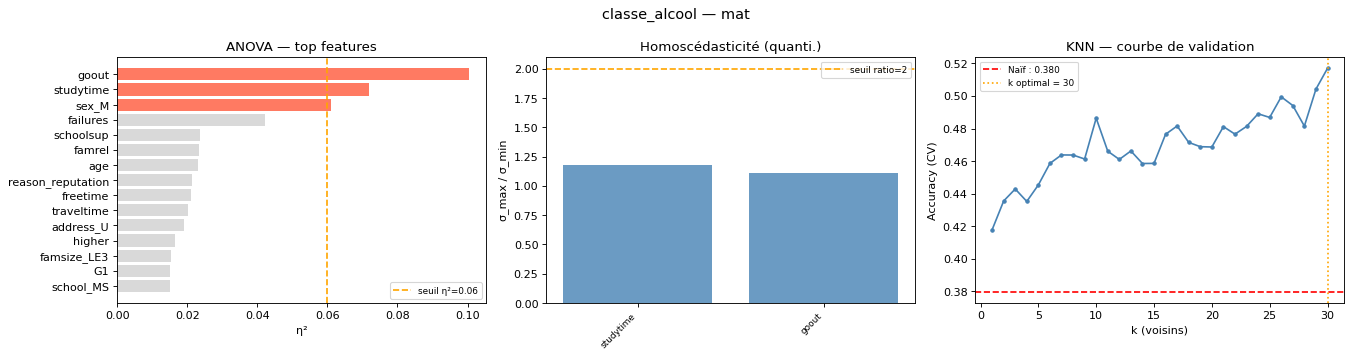

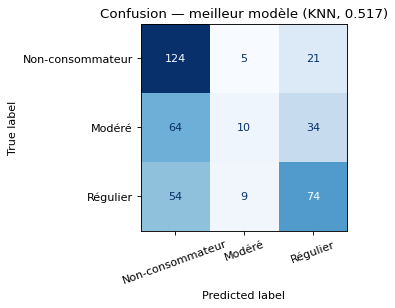

In [5]:
results.append(run_alcool_analysis(student_mat, dataset_label='mat'))

---
## 5. student-por

=== classe_alcool — por (n=649) ===
Répartition : Non-consommateur=241, Modéré=180, Régulier=228   (naïf = 0.371)
Features retenues (η² > 0.06) : ['goout', 'sex_M']
Ratios σ_max/σ_min (variables quantitatives) : {'goout': 1.05}
✅ Homoscédasticité respectée (tous les ratios ≤ 2) → LDA est le choix théoriquement justifié ici.

Naïf                  : 0.371
KNN (k= 9)         : 0.470
LDA (sans shrinkage)  : 0.470 ± 0.061   [LDA justifié]
QDA (sans reg_param)  : 0.488 ± 0.067
Régression logistique : 0.470 ± 0.061


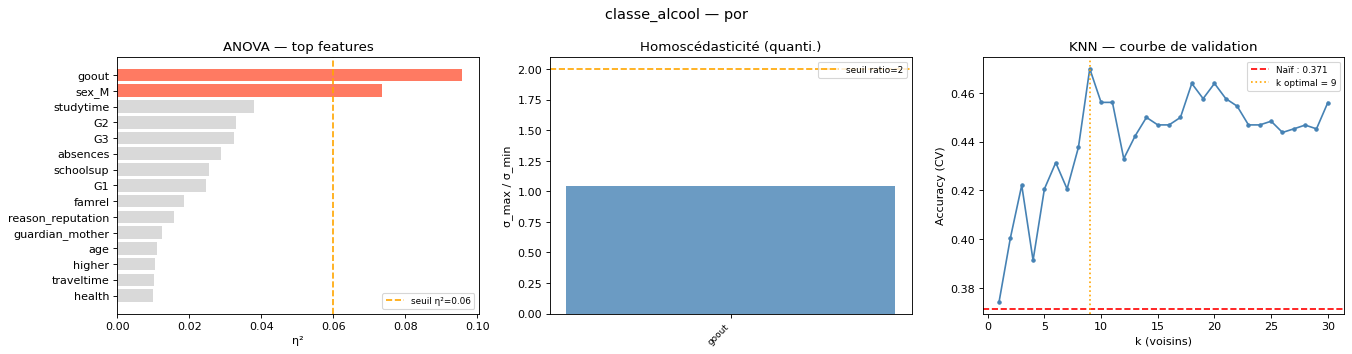

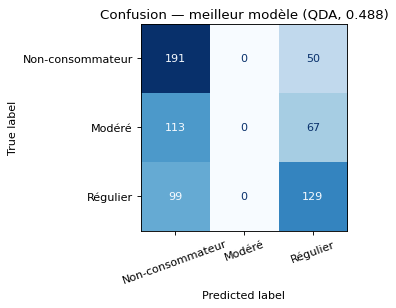

In [6]:
results.append(run_alcool_analysis(student_por, dataset_label='por'))

---
## 6. Où se situe `classe_alcool` ? — entre clusters et oracle, et le verdict ne change pas avec le rééquilibrage

### Le verdict du graphique ANOVA reste sans appel : les notes ne portent (presque) aucun signal

| Feature | η² (mat) | η² (por) |
|---|---|---|
| `goout` (sorties entre amis) | **0.100** | **0.096** |
| `studytime` | **0.072** | 0.038 |
| `sex_M` (être un garçon) | **0.061** | **0.073** |
| `failures` | 0.042 | — |
| `G2` | — | 0.033 |
| `G3` | — | 0.032 |
| `G1` | — | 0.025 |

Le rééquilibrage des classes change un peu les valeurs (et fait basculer `studytime` de part et d'autre du
seuil entre `mat` et `por`), mais **la hiérarchie de fond ne bouge pas d'un pouce** : `goout` et `sex_M`
dominent toujours largement, et **aucune note ne s'approche du seuil η² > 0.06** (`G1`/`G2`/`G3` plafonnent
à 0.025-0.033, cinq fois moins que `goout`). Réponse à la question posée en introduction, désormais
confirmée sur deux découpages différents de la cible : **la consommation d'alcool n'est pas liée aux
résultats scolaires** dans ce jeu de données. Ce n'est pas un artefact du choix des seuils — le signal
ignore les notes quelle que soit la façon dont on découpe `classe_alcool`.

### Ce qui porte vraiment le signal : vie sociale, temps d'étude et genre

`goout` reste la variable la plus discriminante des deux côtés, suivie de près par `sex_M`. `studytime`
gagne en importance côté `mat` (0.072, contre 0.079 dans la version originale — stable) : moins de temps
d'étude, plus de consommation, un lien plausible (le même temps disponible se partage entre sorties et
travail). Trois variables interprétables, cohérentes avec l'intuition sur les comportements adolescents —
toujours pas de fourre-tout statistique.

### Homoscédasticité — toujours respectée naturellement, le rééquilibrage n'a rien changé à ça

Les ratios σ_max/σ_min restent proches de 1 (`mat` : `studytime`=1.18, `goout`=1.11 ; `por` : `goout`=1.05) —
bien en-dessous du seuil de 2. **L'homoscédasticité reste respectée d'emblée**, ce qui désigne toujours
**LDA comme le choix théoriquement justifié**. C'est d'ailleurs rassurant méthodologiquement : rééquilibrer
les classes a changé leurs effectifs, mais pas la dispersion interne des variables explicatives — signe que
le rééquilibrage a vraiment résolu un problème de *taille* de classes, sans introduire de nouvelle
hétérogénéité.

Le résultat empirique est cependant un peu plus nuancé qu'avec l'ancien découpage : sur `mat`, LDA
(0.510) reste au coude-à-coude avec KNN (le meilleur, à 0.517) et la régression logistique (0.510) ; mais
sur `por`, c'est cette fois **QDA qui prend la tête** (0.488), légèrement devant LDA/KNN/LogReg (0.470
chacun) — alors même que l'homoscédasticité y est respectée et désigne LDA comme le choix « propre ». Ce
n'est pas une contradiction : avec un ratio de 1.05, la situation est à la limite de l'homogénéité parfaite,
et un tout petit écart résiduel de variance peut suffire à faire pencher la balance de quelques millièmes —
un rappel utile que la frontière LDA/QDA n'est jamais un couperet net, et que sur un signal aussi ténu
(seulement 2 variables retenues sur `por`), l'écart entre les modèles tient surtout au bruit
d'échantillonnage plus qu'à un vrai avantage structurel de l'un sur l'autre.

### Le positionnement final : ni cluster, ni oracle — et un naïf désormais honnête

| | Naïf (avant → après) | Meilleur modèle | Gain |
|---|---|---|---|
| `mat` | 0.441 → **0.380** | **0.517** (KNN, k=30) | **+13.7 pts** |
| `por` | 0.448 → **0.371** | **0.488** (QDA) | **+11.7 pts** |

Le rééquilibrage a un effet inattendu et bienvenu : en faisant retomber le naïf de ≈ 0.44 à ≈ 0.37-0.38, il
**augmente le gain apparent** des modèles (+13.7 et +11.7 points, contre +10.9 et +7.3 avec l'ancien
découpage) — non pas parce que les modèles prédisent mieux dans l'absolu (les accuracies brutes sont même
légèrement plus basses), mais parce que **le point de comparaison est désormais le bon**. C'est exactement
la même leçon que celle tirée du passage aux tertiles pour le niveau scolaire : un naïf gonflé par des
classes déséquilibrées masque le vrai écart entre « deviner » et « prédire ».

`classe_alcool` reste positionnée loin des clusters K-means (85-93%, largement circulaires) et nettement
au-dessus de l'oracle (où la quasi-totalité des cibles ne dépassait pas le naïf). Le rééquilibrage n'a donc
pas changé *où* se situe cette variable entre les deux extrêmes — il a surtout rendu cette position plus
honnête à lire, et confirmé, sur une base statistique plus saine, que le signal repose entièrement sur le
profil social et démographique de l'élève — jamais sur ses résultats scolaires.

## Conclusion — une troisième pièce qui complète le tableau

Avec ce notebook, le projet a maintenant exploré trois directions de prédiction supervisée, chacune
éclairant les deux autres :

| Cible | Nature | Notes incluses ? | Meilleure accuracy | Lecture |
|---|---|---|---|---|
| **Clusters K-means** | Artificielle (géométrique) | Oui (elles ont servi à construire les clusters) | 85-93% | Très prédictible — mais largement *circulaire* : les clusters sont une fonction directe des variables qui les "prédisent" ensuite |
| **Variables oracle** (`famsup`, `romantic`...) | Réelle, comportementale | Non pertinent (pas de notes utiles détectées) | ≈ naïf | Quasi imprédictible — ces comportements sont statistiquement indépendants du contexte scolaire/familial disponible |
| **Niveau scolaire** (`apprentissage_reussite`) | Dérivée des notes (tertiles) | Non (exclues — fuite directe) | mat : 0.440 / por : 0.547 | Signal réel et modeste, porté par `failures`, `higher`, `Medu` — l'historique scolaire et le contexte familial expliquent un peu, pas tout |
| **`classe_alcool`** (ce notebook, classes rééquilibrées) | Réelle, comportementale | **Oui** (légitime — pas de fuite) | mat : 0.517 / por : 0.488 | Signal réel et modeste, mais porté par la **vie sociale, le temps d'étude et le genre** — *jamais* par les notes ni le contexte familial. Confirmé sur deux découpages différents de la cible (seuils originaux et seuils rééquilibrés) : la hiérarchie des prédicteurs ne bouge pas |

Le résultat le plus intéressant n'est peut-être pas le chiffre d'accuracy, mais ce qu'il révèle en creux :
**chaque variable a sa propre "signature" de prédicteurs**, et ces signatures ne se recoupent pas. Le
contexte familial/scolaire explique (un peu) le niveau scolaire ; la vie sociale, le temps d'étude et le
genre expliquent (un peu) la consommation d'alcool ; et rien dans ce jeu de données n'explique vraiment le
soutien familial perçu ou la vie amoureuse. Avoir testé les trois — avec la même rigueur méthodologique
(sélection ANOVA, vérification systématique des hypothèses, mêmes modèles comparés dans les mêmes
conditions) — permet de l'affirmer avec une vraie confiance, plutôt que de se contenter d'un chiffre isolé
dont on ne saurait pas s'il reflète un vrai signal ou un artefact de construction.

**Un dernier détail, presque anecdotique mais révélateur** : retravailler `classe_alcool` pour obtenir des
classes plus homogènes n'a strictement rien changé à la conclusion de fond (mêmes variables dominantes,
même verdict d'homoscédasticité, même position relative entre clusters et oracle) — mais a fait apparaître
un gain *apparent* plus net (+13.7 et +11.7 points contre +10.9 et +7.3), simplement en ramenant le naïf à
sa vraie valeur de référence. Un signal est resté le même signal ; seule la règle pour le mesurer est devenue
plus honnête. C'est, encore une fois, la même leçon que celle du passage aux tertiles pour le niveau
scolaire — répétée ici sur une cible différente, ce qui est la meilleure façon de vérifier qu'elle n'était
pas un coup de chance.